# Crime_Complaints_And_Arrests_NYC_Data_Project

### 1. What percentage of 2025 arrests involved each sex?
### 2. What percentage of 2025 arrests involved each race?
### 3. How do race arrest rates differ by borough?
### 4. How do arrests compare with complaints across NYC neighborhoods?


In [1]:
import pandas as pd 
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
complaints = pd.read_csv("complaints_2025.csv")
complaints

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [3]:
arrests = pd.read_csv("arrests_2025.csv")
arrests

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,lon_lat
0,318204904,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650101,M,K,81,0,45-64,M,BLACK,1003127,187889,40.682369,-73.931939,POINT (-73.93193899 40.6823685)
1,318192907,2025-12-31T00:00:00.000,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200501,F,M,14,0,(null),(null),WHITE HISPANIC,985802,213780,40.753463,-73.994399,POINT (-73.994399 40.753463)
2,318209021,2025-12-31T00:00:00.000,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
3,318198593,2025-12-31T00:00:00.000,113,"MENACING,UNCLASSIFIED",344.0,ASSAULT 3 & RELATED OFFENSES,PL 1201401,M,Q,104,0,45-64,M,WHITE,1011377,197016,40.707408,-73.902155,POINT (-73.902155 40.707408)
4,318202619,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650102,M,M,14,0,25-44,M,BLACK,986568,214237,40.754707,-73.991633,POINT (-73.99163337 40.75470724)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278948,298746555,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,B,41,0,(null),(null),BLACK,1011695,237702,40.819081,-73.900845,POINT (-73.900845 40.819081)
278949,298714540,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,66,0,18-24,M,WHITE HISPANIC,984348,168623,40.629519,-73.999648,POINT (-73.999648 40.629519)
278950,298710709,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL05110MU,M,B,44,0,(null),(null),BLACK,1009324,247086,40.844833,-73.909375,POINT (-73.90937492396961 40.84483348116061)
278951,298748907,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,K,81,2,(null),(null),BLACK,1001545,187376,40.680964,-73.937644,POINT (-73.93764421223999 40.6809636649715)


## Data cleaning

In [4]:
arrests[["arrest_date", "perp_sex", "perp_race"]].dtypes

arrest_date    str
perp_sex       str
perp_race      str
dtype: object

In [5]:
arrests["arrest_date"] = pd.to_datetime(arrests["arrest_date"])
arrests["perp_sex"] = arrests["perp_sex"].replace({"M": "Male", "F": "Female", "(null)": "Unknown"})
arrests["perp_race"] = arrests["perp_race"].replace({"UNKNOWN": "Unknown", "(null)": "Unknown"})

## Arrests by race

In [6]:
race = arrests.loc[arrests["perp_race"] != "Unknown", "perp_race"].str.title()
race_counts = race.value_counts().rename_axis("Race").reset_index(name="Count")

In [7]:
race_counts["Percentage"] = race_counts["Count"] / race_counts["Count"].sum() * 100

race_counts

,Race,Count,Percentage
0,Black,134262,48.295857
1,White Hispanic,69712,25.076349
2,White,29013,10.436368
3,Black Hispanic,27764,9.987086
4,Asian / Pacific Islander,16261,5.849302
5,American Indian/Alaskan Native,987,0.355037


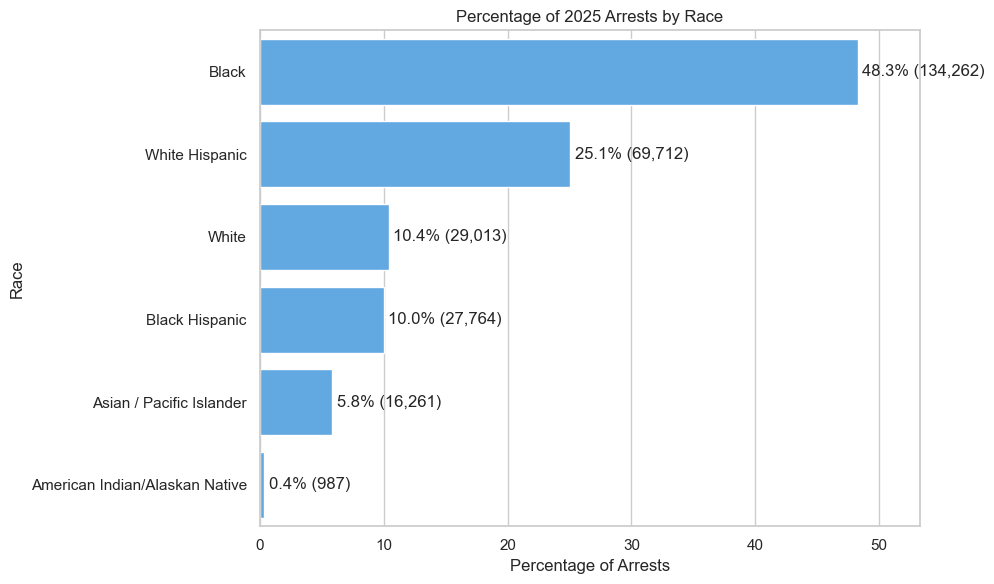

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=race_counts, x="Percentage", y="Race", color="#4DABF7")
labels = [f"{percentage:.1f}% ({count:,})" for percentage, count in zip(race_counts["Percentage"], race_counts["Count"])]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

ax.set(
    title="Percentage of 2025 Arrests by Race",
    xlabel="Percentage of Arrests",
    ylabel="Race",
    xlim=(0, race_counts["Percentage"].max() + 5)
)
plt.tight_layout()
plt.show()

## Arrests by sex

*Note: 147,237 arrests (52.78%) had unknown sex and were excluded.*

In [9]:
sex = arrests.loc[arrests["perp_sex"] != "Unknown", "perp_sex"]
sex_counts = sex.value_counts().rename_axis("Sex").reset_index(name="Count")

In [10]:
sex_counts["Percentage"] = sex_counts["Count"] / sex_counts["Count"].sum() * 100

sex_counts

,Sex,Count,Percentage
0,Male,108874,82.658143
1,Female,22842,17.341857


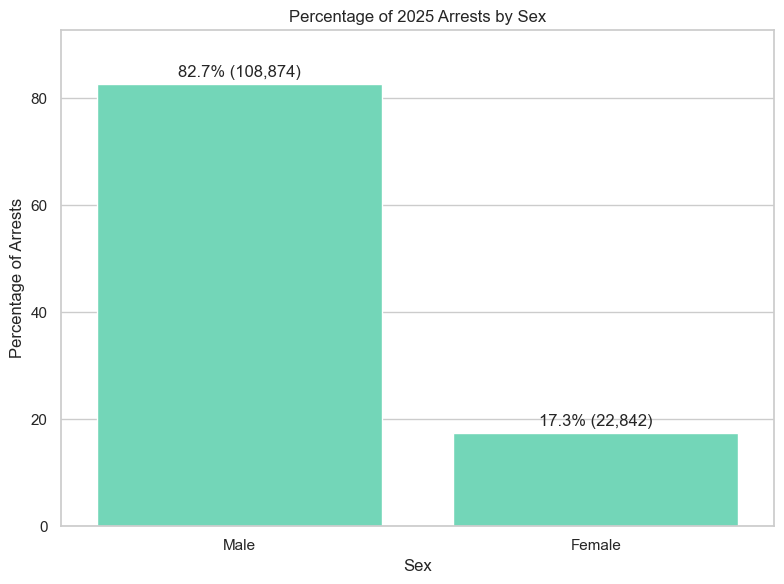

In [11]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=sex_counts, x="Sex", y="Percentage", color="#63E6BE")
labels = [f"{percentage:.1f}% ({count:,})" for percentage, count in zip(sex_counts["Percentage"], sex_counts["Count"])]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

ax.set(
    title="Percentage of 2025 Arrests by Sex",
    xlabel="Sex",
    ylabel="Percentage of Arrests",
    ylim=(0, sex_counts["Percentage"].max() + 10)
)
plt.tight_layout()
plt.show()

## 2025 population by race and borough

Source: [U.S. Census Bureau Vintage 2025 Population Estimates](https://www.census.gov/programs-surveys/popest/data/tables.html)

In [12]:
census_url = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/counties/asrh/cc-est2025-alldata-36.csv"
census = pd.read_csv(census_url, encoding="latin-1")

In [13]:
borough_counties = [5, 47, 61, 81, 85]

borough_population = census.query("COUNTY in @borough_counties and YEAR == 7 and AGEGRP == 0").copy()

In [14]:
borough_names = {5: "Bronx", 47: "Brooklyn", 61: "Manhattan", 81: "Queens", 85: "Staten Island"}
borough_population["Borough"] = borough_population["COUNTY"].map(borough_names)

In [15]:
race_population = pd.DataFrame()
race_population["Borough"] = borough_population["Borough"]

In [16]:
race_population["BLACK"] = borough_population["NHBA_MALE"] + borough_population["NHBA_FEMALE"]
race_population["WHITE"] = borough_population["NHWA_MALE"] + borough_population["NHWA_FEMALE"]

In [17]:
race_population["WHITE HISPANIC"] = borough_population["HWA_MALE"] + borough_population["HWA_FEMALE"]
race_population["BLACK HISPANIC"] = borough_population["HBA_MALE"] + borough_population["HBA_FEMALE"]

In [18]:
race_population["ASIAN / PACIFIC ISLANDER"] = borough_population["AA_MALE"] + borough_population["AA_FEMALE"] + borough_population["NA_MALE"] + borough_population["NA_FEMALE"]
race_population["AMERICAN INDIAN/ALASKAN NATIVE"] = borough_population["IA_MALE"] + borough_population["IA_FEMALE"]

In [19]:
race_population = race_population.melt(id_vars="Borough", var_name="Race", value_name="Population")

## Race arrest rates by borough

In [20]:
borough_codes = {"B": "Bronx", "K": "Brooklyn", "M": "Manhattan", "Q": "Queens", "S": "Staten Island"}
arrests["Borough"] = arrests["arrest_boro"].map(borough_codes)

race_arrests = arrests[arrests["perp_race"] != "Unknown"]
race_arrests = race_arrests.groupby(["Borough", "perp_race"]).size().reset_index(name="Arrests")
race_arrests.columns = ["Borough", "Race", "Arrests"]

In [21]:
race_rates = race_arrests.merge(race_population, on=["Borough", "Race"])
race_rates["Arrests per 100,000"] = race_rates["Arrests"] / race_rates["Population"] * 100000

race_rates

,Borough,Race,Arrests,Population,"Arrests per 100,000"
0,Bronx,AMERICAN INDIAN/ALASKAN NATIVE,150,73597,203.812655
1,Bronx,ASIAN / PACIFIC ISLANDER,982,86974,1129.073056
2,Bronx,BLACK,29758,389735,7635.444597
3,Bronx,BLACK HISPANIC,11409,246594,4626.633251
4,Bronx,WHITE,2116,120926,1749.830475
5,Bronx,WHITE HISPANIC,18161,407775,4453.681565
6,Brooklyn,AMERICAN INDIAN/ALASKAN NATIVE,225,53757,418.550142
7,Brooklyn,ASIAN / PACIFIC ISLANDER,4470,396290,1127.961846
8,Brooklyn,BLACK,45013,697069,6457.466908
9,Brooklyn,BLACK HISPANIC,4551,129039,3526.840723


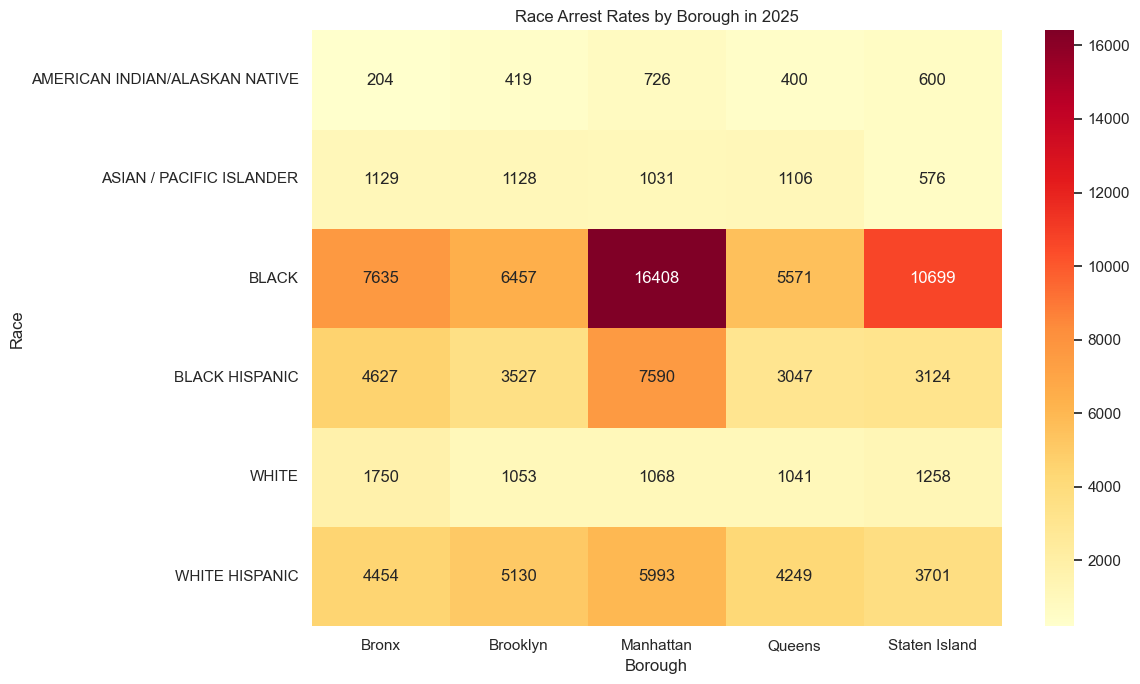

In [22]:
race_heatmap = race_rates.pivot(index="Race", columns="Borough", values="Arrests per 100,000")
race_heatmap = race_heatmap[["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]]

plt.figure(figsize=(12, 7))
sns.heatmap(race_heatmap, annot=True, fmt=".0f", cmap="YlOrRd")

plt.title("Race Arrest Rates by Borough in 2025")
plt.xlabel("Borough")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

## 2025 arrests by NYC neighborhood

*The map shows where arrests happened, not where the arrested people live.*

In [23]:
nta = gpd.read_file("nynta2020_26b/nynta2020.shp")

In [24]:
arrest_points = arrests.dropna(subset=["latitude", "longitude"]).copy()

In [25]:
arrest_points = gpd.GeoDataFrame(
    arrest_points,
    geometry=gpd.points_from_xy(
        arrest_points["longitude"],
        arrest_points["latitude"]
    ),
    crs="EPSG:4326"
)

arrest_points = arrest_points.to_crs(nta.crs)

In [26]:
arrest_nta = gpd.sjoin(
    arrest_points,
    nta[["NTA2020", "NTAName", "geometry"]],
    how="inner",
    predicate="within"
)

In [27]:
arrest_counts = arrest_nta.groupby("NTA2020")["arrest_key"].nunique()
arrest_counts = arrest_counts.reset_index(name="arrest_count")

In [28]:
arrest_map = nta.merge(arrest_counts, on="NTA2020", how="left")
arrest_map["arrest_count"] = arrest_map["arrest_count"].fillna(0)

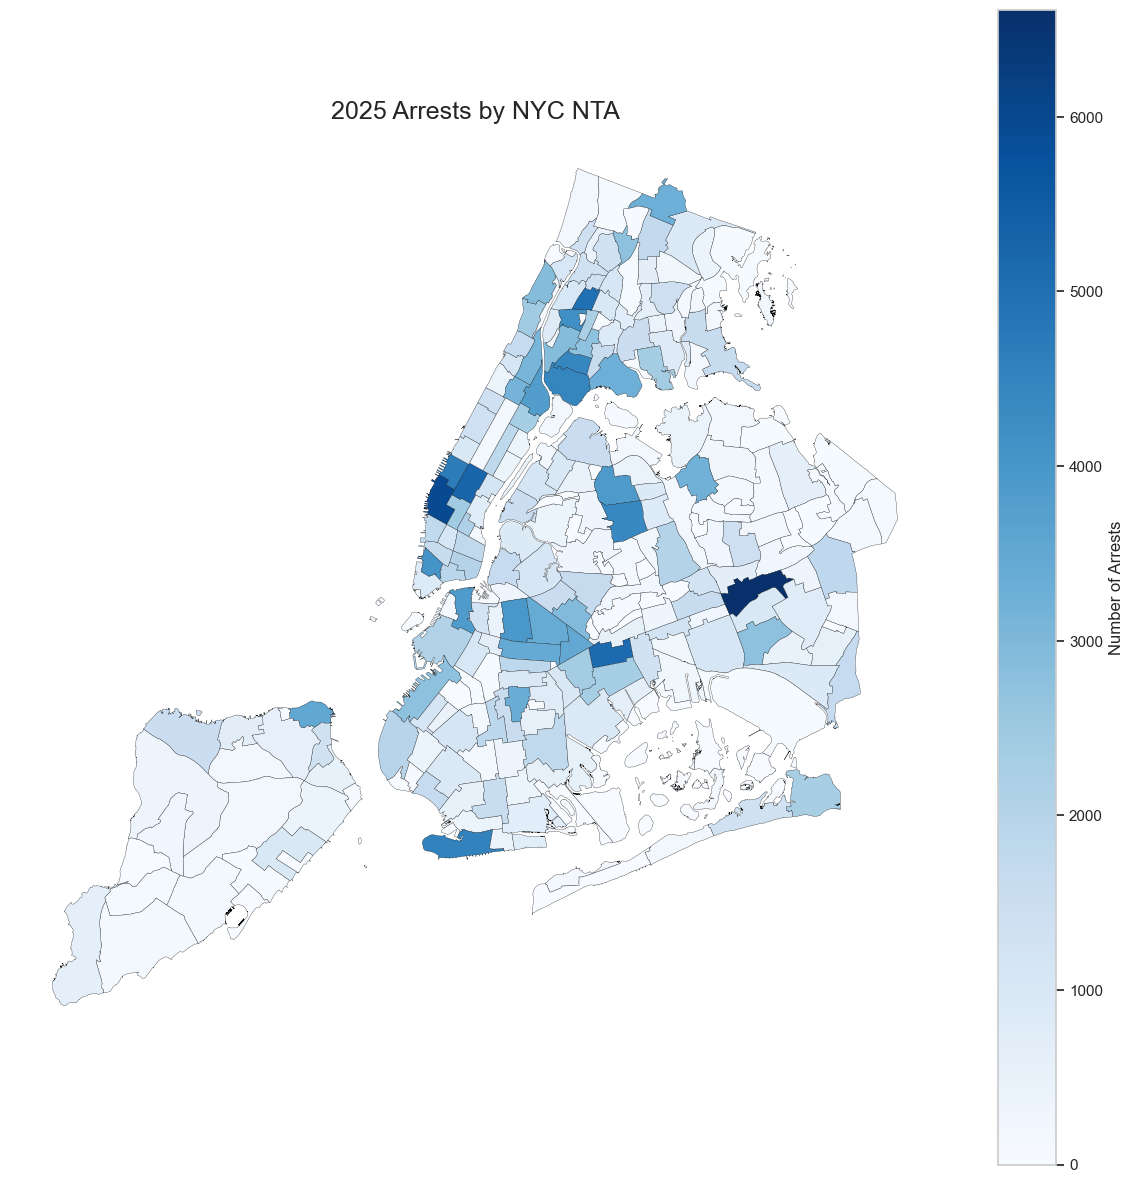

In [29]:
ax = arrest_map.plot(
    column="arrest_count",
    figsize=(15, 15),
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Number of Arrests"}
)

ax.set_title("2025 Arrests by NYC NTA", fontsize=18)
ax.axis("off")
plt.show()

## Arrest share compared with complaint share

*Red areas have a larger share of arrests. Blue areas have a larger share of complaints. This does not show which complaints led to arrests.*

In [30]:
complaint_points = complaints.dropna(subset=["latitude", "longitude"]).copy()

In [31]:
complaint_points = gpd.GeoDataFrame(
    complaint_points,
    geometry=gpd.points_from_xy(
        complaint_points["longitude"],
        complaint_points["latitude"]
    ),
    crs="EPSG:4326"
)

complaint_points = complaint_points.to_crs(nta.crs)

In [32]:
complaint_nta = gpd.sjoin(
    complaint_points,
    nta[["NTA2020", "geometry"]],
    how="inner",
    predicate="within"
)

In [33]:
complaint_counts = complaint_nta.groupby("NTA2020")["cmplnt_num"].nunique()
complaint_counts = complaint_counts.reset_index(name="complaint_count")

In [34]:
comparison = complaint_counts.merge(arrest_counts, on="NTA2020")
comparison["Complaint Share"] = comparison["complaint_count"] / comparison["complaint_count"].sum() * 100
comparison["Arrest Share"] = comparison["arrest_count"] / comparison["arrest_count"].sum() * 100
comparison["Difference"] = comparison["Arrest Share"] - comparison["Complaint Share"]

In [35]:
comparison_map = nta.merge(comparison, on="NTA2020")

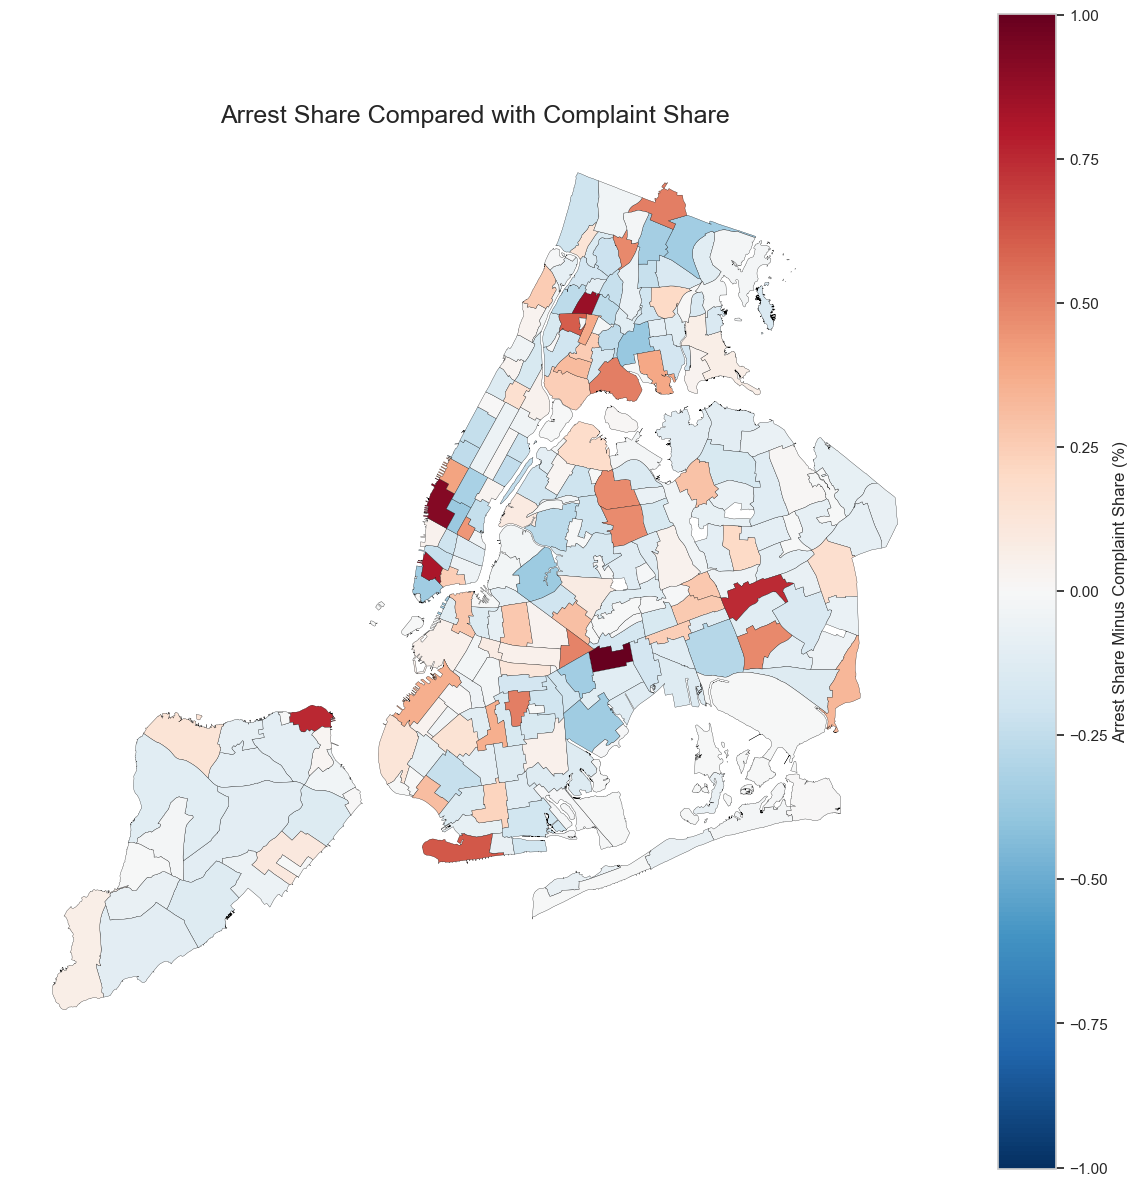

In [36]:
limit = comparison["Difference"].abs().max()

ax = comparison_map.plot(
    column="Difference",
    figsize=(15, 15),
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Arrest Share Minus Complaint Share (%)"}
)

ax.set_title("Arrest Share Compared with Complaint Share", fontsize=18)
ax.axis("off")
plt.show()